#### **Q6. Principle Component Analysis**

**1.)** Extract XBP1 and GATA3 expression levels in all 105 patients, and generate the scatter plot as seen in 1a 

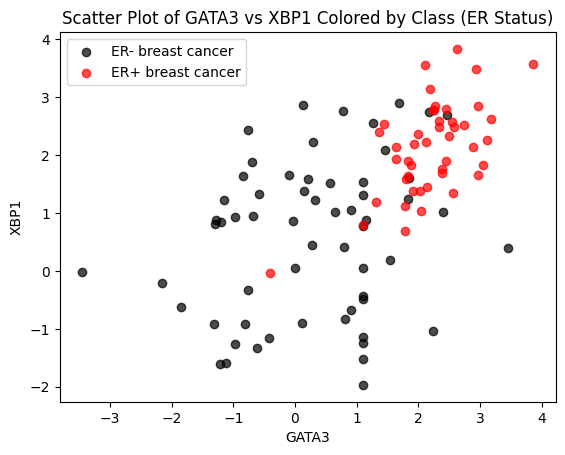

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load expression data (samples x genes)
expression_data = pd.read_csv("filtered.tsv", sep="\t")

class_labels = pd.read_csv("class.tsv", sep="\t", header=None)
gene_info = pd.read_csv("columns.tsv", sep="\t", comment="#")    

# Get column names (IDs) for GATA3 and XBP1 expression values
gata3_id = gene_info.loc[gene_info['GeneSymbol'] == 'GATA3', 'ID'].values[0]
xbp1_id = gene_info.loc[gene_info['GeneSymbol'] == 'XBP1', 'ID'].values[0]
gata3_col = " " + str(gata3_id)
xbp1_col = " " + str(xbp1_id)

gata3_expr = expression_data[gata3_col].values  
xbp1_expr = expression_data[xbp1_col].values  
er_status = class_labels[0].values  

# Create masks for ER- and ER+ samples
er_negative = (er_status == 0)   # ER- breast cancer
er_positive = (er_status == 1)   # ER+ breast cancer

plt.scatter(gata3_expr[er_negative], xbp1_expr[er_negative], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(gata3_expr[er_positive], xbp1_expr[er_positive], color='red', alpha=0.7, label='ER+ breast cancer')

# Labeling and plot formatting
plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Scatter Plot of GATA3 vs XBP1 Colored by Class (ER Status)")
plt.legend()
plt.show()



**2.)** Now,Run PCA on the matrix and project these 2-D points on PC1


### PCA Procedure Overview:
Normalize the data by subtracting the mean (centering)

Calculate the covariance matrix of the features

Determine the eigenvalues and corresponding eigenvectors of the covariance matrix

Rank the eigenvectors based on their eigenvalues in descending order

Select the two leading eigenvectors to serve as the first and second principal components



[3.07186142 0.87054073]


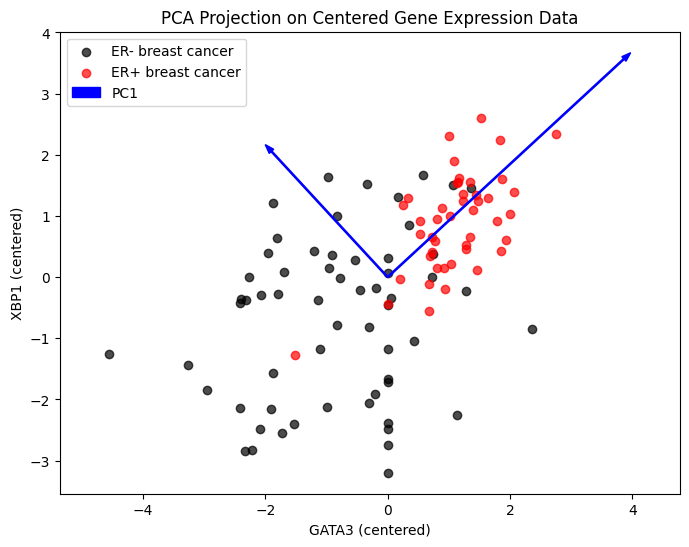

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use previously defined gene expression and class data
gata3_values = gata3_expr
xbp1_values = xbp1_expr
er_labels = er_status

# Combine into a 2D array (samples x features)
expression_matrix = np.vstack((gata3_values, xbp1_values)).T

# Step 1: Center the data by subtracting the mean
mean_vector = np.mean(expression_matrix, axis=0)
centered_matrix = expression_matrix - mean_vector

# Step 2: Compute covariance matrix
cov_mat = np.cov(centered_matrix.T)

# Step 3: Eigen decomposition
eigen_values, eigen_vectors = np.linalg.eig(cov_mat)

print(eigen_values)

# Step 4: Sort eigenvectors by descending eigenvalues
order = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[order]
eigen_vectors = eigen_vectors[:, order]

# Step 5: Extract components and explained variance
principal_components = eigen_vectors.T
explained_variance = eigen_values

# Step 6: Create masks for each class
mask_er_neg = (er_labels == 0)
mask_er_pos = (er_labels == 1)

# Step 7: Plot the centered data and PCA directions
plt.figure(figsize=(8, 6))
plt.scatter(centered_matrix[mask_er_neg, 0], centered_matrix[mask_er_neg, 1], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(centered_matrix[mask_er_pos, 0], centered_matrix[mask_er_pos, 1], color='red', alpha=0.7, label='ER+ breast cancer')

# Draw arrows for PCA directions
for i in range(2):
    plt.arrow(0, 0,
              principal_components[i, 0] * np.sqrt(explained_variance[i]) * 3,
              principal_components[i, 1] * np.sqrt(explained_variance[i]) * 3,
              color='blue', width=0.02, head_width=0.1, label=f'PC{i+1}' if i == 0 else None)

plt.xlabel("GATA3 (centered)")
plt.ylabel("XBP1 (centered)")
plt.title("PCA Projection on Centered Gene Expression Data")
plt.legend()
plt.axis('equal')
plt.show()


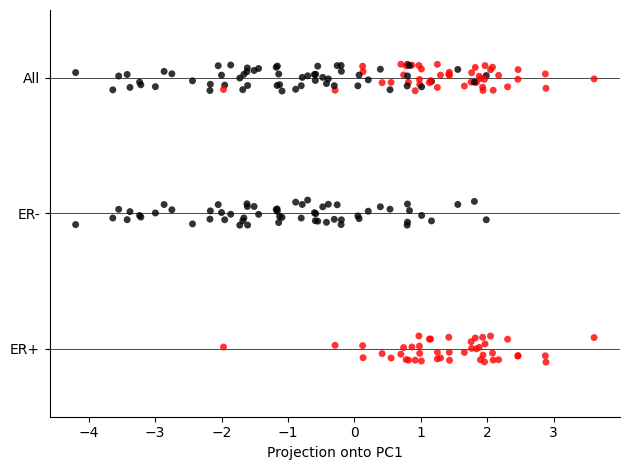

In [3]:
# Project centered data onto first principal component
pc1_dir = principal_components[0, :]
pc1_scores = centered_matrix @ pc1_dir

# Create DataFrames for "All", "ER−", and "ER+" groups
df_combined = pd.DataFrame({
    "PC1": pc1_scores,
    "Group": "All",
    "Color": np.where(er_labels == 0, "black", "red")
})

df_er_neg = pd.DataFrame({
    "PC1": pc1_scores[er_labels == 0],
    "Group": "ER-",
    "Color": "black"
})

df_er_pos = pd.DataFrame({
    "PC1": pc1_scores[er_labels == 1],
    "Group": "ER+",
    "Color": "red"
})

# Merge all into one DataFrame
plot_data = pd.concat([df_combined, df_er_neg, df_er_pos], ignore_index=True)

# Strip plot visualization
ax = sns.stripplot(data=plot_data, x="PC1", y="Group", hue="Color",
                   palette={"black": "black", "red": "red"},
                   dodge=False, jitter=True, alpha=0.8, size=5)

ax.yaxis.grid(True, linestyle='-', color='black', linewidth=0.5, alpha=1.0)

plt.xlabel("Projection onto PC1")
plt.ylabel("")
plt.legend([], [], frameon=False)  # Remove legend
sns.despine()
plt.tight_layout()
plt.show()
